In [111]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from numpy.lib.stride_tricks import sliding_window_view

# Load signal
mat_path = 'Signals_task3/signal3.mat'
data = scipy.io.loadmat(mat_path)
r = data['R'].flatten()

# System parameters
fs = 44100
fc = 10000
Nsc = 128
Ncp = 20
Tsym = 58 * 10**-3


**Demodulation**

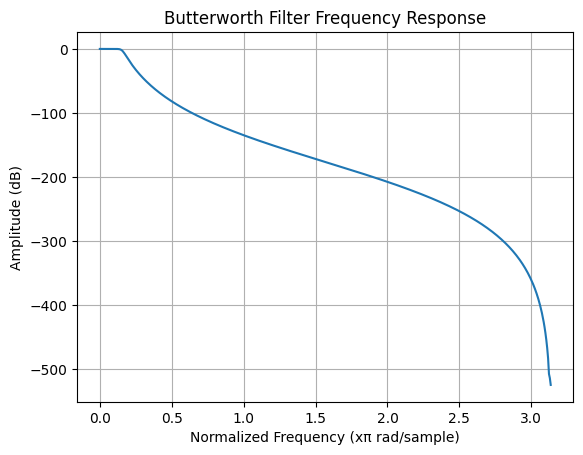

In [112]:
n = np.arange(len(r))
r_I =  2 * r * np.cos(2 * np.pi * fc * n / fs)
r_Q = -2 * r * np.sin(2 * np.pi * fc * n / fs)
from scipy.signal import butter, freqz, filtfilt

b, a = butter(8, 0.05)
r_I_filt = filtfilt(b, a, r_I)
r_Q_filt = filtfilt(b, a, r_Q)

w, h = freqz(b, a)
plt.plot(w, 20 * np.log10(abs(h)))
plt.title('Butterworth Filter Frequency Response')
plt.xlabel('Normalized Frequency (xπ rad/sample)')
plt.ylabel('Amplitude (dB)')
plt.grid()
plt.show()

It shows how the filter attenuates different frequencies, with the x-axis representing the normalized frequency and the y-axis representing the amplitude in decibels (dB). The plot helps to visualize the characteristics of the Butterworth filter, such as its cutoff frequency and roll-off rate. High frequency components are attenuated, while low frequency components are preserved, which is characteristic of a low-pass filter. The cutoff frequency is around 0.05 times the Nyquist frequency, which corresponds to the normalized cutoff frequency used in the Butterworth filter design.

**A/D Conversion and Down Sampling**

In [113]:
D = fs * Tsym / Nsc   # exact ratio, not rounded
idx = np.arange(0, len(r_I_filt), D)
r_I_down = np.interp(idx, np.arange(len(r_I_filt)), r_I_filt)
r_Q_down = np.interp(idx, np.arange(len(r_Q_filt)), r_Q_filt)
r_bb = r_I_down + 1j * r_Q_down
print(f'D={D:.4f}, r_bb length={len(r_bb)}, ~{len(r_bb)//(Nsc+Ncp)} OFDM symbols')

D=19.9828, r_bb length=6359, ~42 OFDM symbols


**Synchronization and Removal of the Cyclic Prefix**

In [ ]:
Tper = Nsc // 2  # = 64, pilot symbol period

wins  = sliding_window_view(r_bb, 2 * Tper)
gamma = np.sum(wins[:, :Tper] * np.conj(wins[:, Tper:]), axis=1)
phi1  = np.sum(np.abs(wins[:, :Tper])**2, axis=1)
phi2  = np.sum(np.abs(wins[:, Tper:])**2, axis=1)
mu    = np.abs(gamma) / np.sqrt(phi1 * phi2 + 1e-10)

T0 = int(np.argmax(mu))     # peak of the Schmidl–Cox plateau
t0 = T0 - Ncp - 1           # start of pilot CP (1 sample of safety margin)
print(f'Pilot CP starts at: {t0}, OFDM data at: {T0}')

Nofdm   = Nsc + Ncp
n_sym   = (len(r_bb) - t0) // Nofdm
ofdm_blocks = r_bb[t0 : t0 + n_sym*Nofdm].reshape(n_sym, Nofdm)
ofdm_data   = ofdm_blocks[:, Ncp:]
print(f'Total OFDM symbols: {n_sym}')

Pilot CP starts at: 4002, OFDM data at: 4023
Total OFDM symbols: 15


**FFT**

In [115]:
X = np.fft.fft(ofdm_data, axis=1)

**Channel estimation**

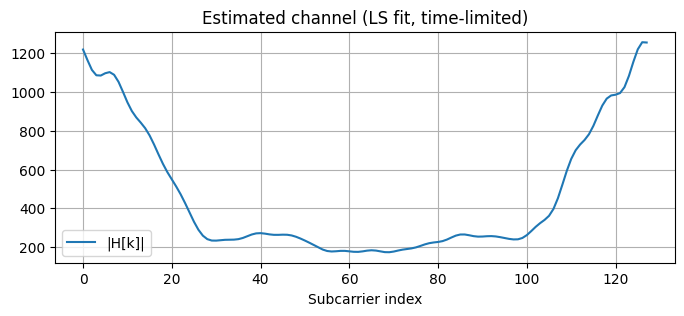

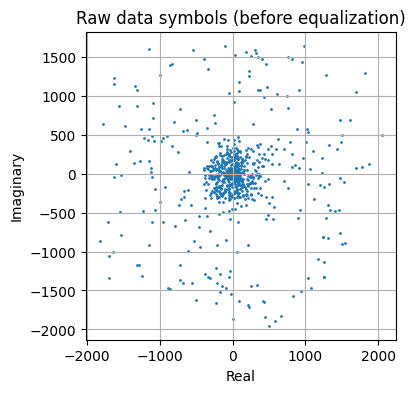

In [ ]:
# Channel estimation by least-squares fit of a TIME-LIMITED impulse response.
# This is the OFDM-correct approach: the channel has memory ≤ Ncp (otherwise
# the cyclic prefix would not protect the symbol). With L ≤ Ncp time-domain
# taps h[0..L-1], every subcarrier satisfies
#       H[k] = sum_l h[l] * exp(-j 2π l k / Nsc).
# We fit h to the subcarriers whose transmitted value is known:
#   - length symbol (X[1]): subcarriers 15..127 carry the all-zero bit padding,
#     which the QPSK map sends as 1+j  (since 00 → 1+i in the project spec)
#   - pilot symbol  (X[0]): even subcarriers carry 2*P[k] with the Matlab
#     reference sequence (randn('state',100); P = sign(randn(1,Nsc/2))).
# Linear interpolation across pilots is what was failing before — it cannot
# represent the smooth complex variation imposed by a multi-tap channel and
# the residual phase ramp from sub-sample sync error.

# P sequence reproduced from Matlab randn('state',100); sign(randn(1,Nsc/2))
P = np.array([
    1, -1, -1,  1, -1, -1, -1, -1,  1,  1,  1,  1, -1, -1, -1, -1,
    1,  1, -1,  1, -1, -1,  1, -1,  1,  1,  1, -1, -1,  1, -1,  1,
   -1,  1, -1,  1,  1, -1,  1,  1, -1,  1,  1,  1, -1, -1,  1,  1,
    1,  1,  1, -1,  1,  1,  1, -1,  1,  1, -1,  1,  1, -1,  1, -1,
])

L = Ncp                                  # impulse response length ≤ Ncp
known_k = np.concatenate([np.arange(15, Nsc), np.arange(0, Nsc, 2)])
known_H = np.concatenate([X[1, 15:] / (1 + 1j),
                          X[0, 0::2] / (2 * P)])

A = np.exp(-1j * 2 * np.pi * np.outer(known_k, np.arange(L)) / Nsc)
h, *_ = np.linalg.lstsq(A, known_H, rcond=None)

F_full = np.exp(-1j * 2 * np.pi * np.outer(np.arange(Nsc), np.arange(L)) / Nsc)
H_full = F_full @ h

plt.figure(figsize=(8, 3))
plt.plot(np.abs(H_full), label='|H[k]|')
plt.title('Estimated channel (LS fit, time-limited)')
plt.xlabel('Subcarrier index'); plt.grid(); plt.legend(); plt.show()

plt.figure(figsize=(4, 4))
plt.scatter(X[2:8].real.flatten(), X[2:8].imag.flatten(), s=1)
plt.title('Raw data symbols (before equalization)')
plt.xlabel('Real'); plt.ylabel('Imaginary'); plt.grid(); plt.show()

**Remove pilots**

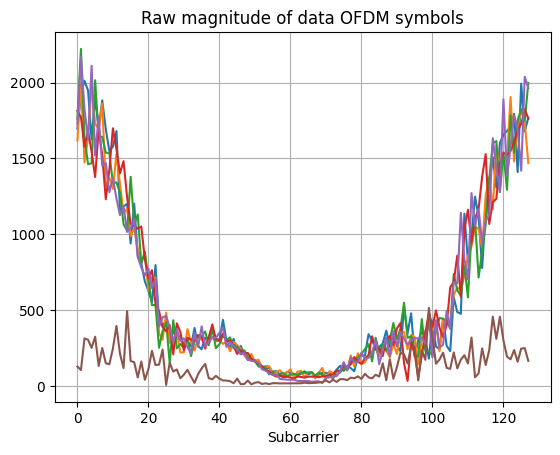

In [117]:
X_data = X[1:]   # length symbol + all remaining symbols
plt.plot(np.abs(X[2:8]).T)
plt.title('Raw magnitude of data OFDM symbols'); plt.xlabel('Subcarrier'); plt.grid(); plt.show()

**Equalization**

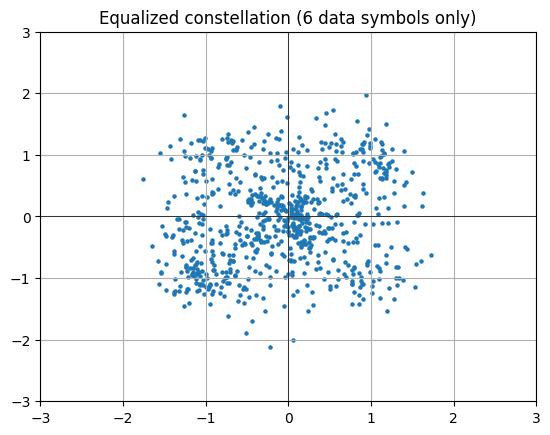

In [ ]:
X_eq = X_data / H_full   # equalize: divide each row by H estimate

# Plot only the 6 actual data symbols (X_eq[0]=length, X_eq[1:7]=data)
plt.scatter(X_eq[1:7].real.flatten(), X_eq[1:7].imag.flatten(), s=5)
plt.xlim(-3, 3); plt.ylim(-3, 3)
plt.axhline(0, color='k', lw=0.5); plt.axvline(0, color='k', lw=0.5)
plt.title('Equalized constellation (6 data symbols only)')
plt.grid(); plt.show()

**QPSK DEMOD**

In [120]:
bits = []
for sym in X_eq.flatten():
    bits.append('1' if sym.real < 0 else '0')
    bits.append('1' if sym.imag < 0 else '0')

**Decoding and ASCII**

In [ ]:
from commpy.channelcoding import Trellis, viterbi_decode

# (77,45) rate-1/2 convolutional code, memory 5.
# CommPy's g_matrix uses the bit-reversed convention compared with the Matlab
# (77,45) octal naming, so we encode the second polynomial as 0o51 = 0o45 with
# the 6 coefficient bits reversed.
trellis = Trellis(memory=np.array([5]), g_matrix=np.array([[0o77, 0o51]]))

bits_arr = np.array(bits).astype(int).astype(float)

# Length OFDM symbol = X_eq[0] = first 256 bits.
# Only the first 30 of those (15 QPSK symbols) carry the conv-encoded length;
# the remaining 226 are the QPSK image of the all-zero padding (= 1+j).
bits_len = bits_arr[:30]
decoded_len = viterbi_decode(bits_len, trellis, tb_depth=15, decoding_type='hard')
l_m = int(''.join(decoded_len[:10].astype(int).astype(str)), 2)
print(f'Decoded message length: {l_m} characters')

# Data starts in X_eq[1] = bits_arr[256:]. We need 14*l_m + 10 coded bits.
bits_data = bits_arr[256:]
needed = 14 * l_m + 10
decoded_msg = viterbi_decode(bits_data[:needed], trellis, decoding_type='hard')
msg_bits = decoded_msg[:7 * l_m].astype(int).astype(str)
message = ''.join(
    chr(int(''.join(msg_bits[i:i + 7]), 2))
    for i in range(0, 7 * l_m, 7)
)
print(message)

Decoded message length: 104 characters
Any linear combination of Gaussian random variables is again 9@GaYllG1n random,\L(VC`.  {g1#V   `
